In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from drs4_parser.parser import event_stream, read_first_n, file_properties
from drs4_parser.parser import print_file_properties
from drs4_parser.events_filter.coincidence import event_coincidence_filter
from drs4_parser.time_analysis import cfd_linear, cfd_analog_time
from drs4_parser.pals import good_event, read_lifetime

from drs4_parser.energy_analysis.baseline import baseline_estimation
from drs4_parser.energy_analysis.pulse_height import pulse_height_3pts_parabolic, pulse_height_robust

file parameters

In [3]:
# --------- CONFIG ---------
bin_file = "F:/Data/lifetime/drs4_bin.dat"
max_events = 10000
channels = file_properties(bin_file).channels[1:]
BINS_IN_WAVEFORM = 1024
# --------------------------


read events

In [4]:
da = read_first_n(bin_file, max_events)

pars te events by puels height

In [5]:
ch1_t, ch1_v = da['time'].sel(channel=[channels[0]]).values[0], da['voltage'].sel(channel=[channels[0]]).values[0]
ch2_t, ch2_v = da['time'].sel(channel=[channels[1]]).values[0], da['voltage'].sel(channel=[channels[1]]).values[0]

ch1_height = -pulse_height_robust(ch1_t, ch1_v)
ch2_height = -pulse_height_robust(ch2_t, ch2_v)

ch1_count, ch1_bins = np.histogram(ch1_height[np.isfinite(ch1_height)], bins=1024)
ch2_count, ch2_bins = np.histogram(ch2_height[np.isfinite(ch2_height)], bins=1024)

# plot

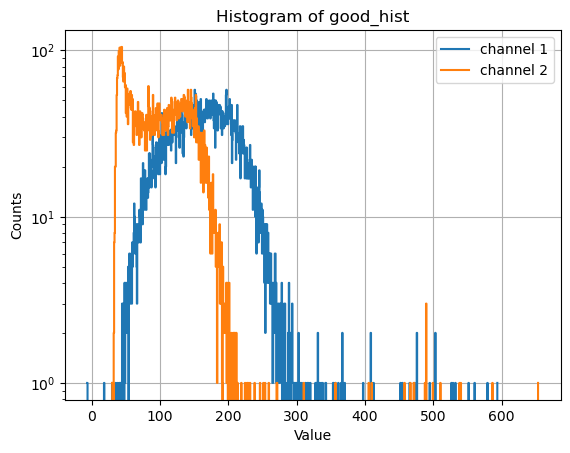

In [6]:
plt.step(ch2_bins[:-1], ch2_count, where='post', label='channel 1')  # 'post' aligns steps correctly
plt.step(ch1_bins[:-1], ch1_count, where='post', label='channel 2')  # 'post' aligns steps correctly

plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Histogram of good_hist")
plt.yscale('log')
plt.grid()
plt.legend()